# Le critere de Kelly — compagnon Python du lake `kelly_lean`

Ce notebook est le **volet numerique** de la preuve formelle
[`kelly_lean`](./Kelly/Kelly.lean) (Lean 4 + Mathlib). Il montre, cote a cote
avec les theoremes prouves, **pourquoi** la fraction de Kelly

$$f^\star = \frac{b\,p - q}{b}, \qquad q = 1-p$$

maximise le **taux de croissance espere du capital compose**

$$g(f) = p\,\log(1 + b\,f) + q\,\log(1 - f),$$

et pourquoi tout sur-pari ($f > f^\star$) ou sous-pari ($f < f^\star$) est
strictement sous-optimal.

> **Paire Lean + Python** : le resultat mathematique rigoureux vit dans le
> lake Lean ci-dessous ; ce notebook l'illustre numeriquement (courbe de
> croissance, simulation Monte-Carlo) et l'utilise comme outil de *position
> sizing* — un concept central de la serie trading QuantConnect.

### Theoremes prouves dans `kelly_lean` (rappel)

| Symbole Lean | Enonce |
|---|---|
| `kellyFrac β` | $f^\star = (b\,p - q)\,/\,b$ |
| `kelly_optimal` | pour toute fraction admissible $f$, $g(f) \le g(f^\star)$ |
| `kelly_unique` | si $f \ne f^\star$ est admissible, alors $g(f) < g(f^\star)$ |

La condition d'admissibilite `Feasible β f` est $f \in (-1/b,\, 1)$ : on garde
une richesse strictement positive dans les deux issues (gain et perte).

## 1. Le pari de Bernoulli

On parie une fraction $f$ du capital sur un evenement binominal :
- avec probabilite $p$ on **gagne** $b$ fois la mise (cote nette $b$) ;
- avec probabilite $q = 1-p$ on **perd** la mise.

La richesse relative apres l'issue vaut donc $1 + b f$ (gain) ou $1 - f$ (perte).
On choisit $p$ et $b$ tels que le pari soit **favorable** ($b\,p > q$), sinon
$f^\star \le 0$ et le critere dit *ne pas parier*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Pari de Bernoulli : p(gain) = 0.55, cote nette b = 1.0 (1 contre 1)
p = 0.55
b = 1.0
q = 1.0 - p

# Fraction de Kelly : f* = (b*p - q) / b
f_star = (b * p - q) / b
print(f"p = {p}, b = {b}, q = {q}")
print(f"f* (fraction de Kelly) = (b*p - q)/b = {f_star:.4f}")
print(f"Le pari est {'favorable' if f_star > 0 else 'DEFAVORABLE (f* <= 0, ne pas parier)'}")

p = 0.55, b = 1.0, q = 0.44999999999999996
f* (fraction de Kelly) = (b*p - q)/b = 0.1000
Le pari est favorable


## 2. Le taux de croissance espere $g(f)$

Le log-capital espere apres un pari est

$$g(f) = p\,\log(1 + b f) + q\,\log(1 - f).$$

C'est cette grandeur — pas l'esperance de richesse — que l'on maximise, car
c'est le **taux de croissance du capital compose** sur une longue suite de
paris independants (par la loi forte des grands nombres appliquee au
log-capital).

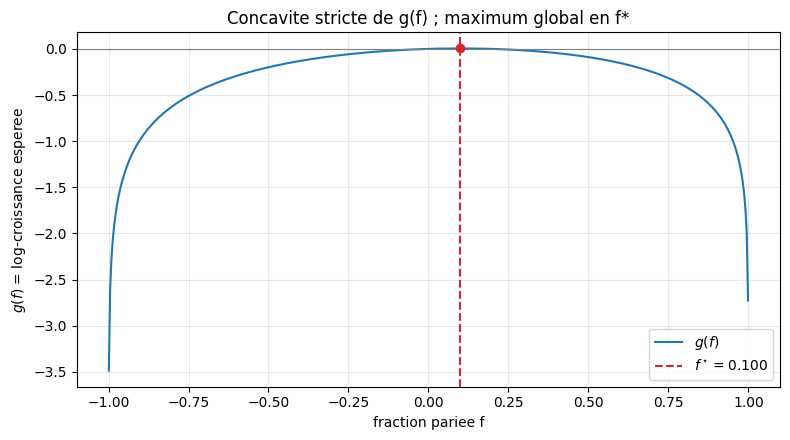

g(f*) = 0.005008
g(0)  = 0.000000  (ne pas parier)


In [2]:
def growth(f, p, b):
    # Taux de croissance espere g(f) = p*log(1+bf) + q*log(1-f).
    q = 1.0 - p
    return p * np.log1p(b * f) + q * np.log1p(-f)

# Domaine admissible f in (-1/b, 1)
f_grid = np.linspace(-1.0 / b + 1e-3, 1.0 - 1e-3, 500)
g_grid = growth(f_grid, p, b)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_grid, g_grid, label=r"$g(f)$", color="#1f77b4")
ax.axvline(f_star, color="#d62728", ls="--", label=rf"$f^\star = {f_star:.3f}$")
ax.axhline(0.0, color="grey", lw=0.8)
ax.scatter([f_star], [growth(f_star, p, b)], color="#d62728", zorder=5)
ax.set_xlabel("fraction pariee f")
ax.set_ylabel(r"$g(f)$ = log-croissance esperee")
ax.set_title("Concavite stricte de g(f) ; maximum global en f*")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"g(f*) = {growth(f_star, p, b):.6f}")
print(f"g(0)  = {growth(0.0, p, b):.6f}  (ne pas parier)")

### Interpretation : $f^\star$ est l'unique maximiseur

La courbe est **strictement concave** : elle admet un unique maximum global
en $f^\star$, et tout autre $f$ admissible donne une croissance strictement
inferieure. C'est exactement ce qu'etablit le theoreme Lean :

```
theorem kelly_unique (β : Bet) (f : ℝ) (hf : Feasible β f) (hfne : f ≠ kellyFrac β) :
    growth β f < growth β (kellyFrac β)
```

- **Sur-pari** ($f > f^\star$) : la croissance diminue, et pour $f \to 1$ la
  perte unique $1-f \to 0$ mene a la **ruine** ($g \to -\infty$).
- **Sous-pari** ($0 < f < f^\star$) : croissance positive mais sous-optimale ;
  on laisse du rendement sur la table en echange d'une volatilite plus faible
  ( idee de base du *fractional Kelly* ).

## 3. Verification Monte-Carlo : $f^\star$ maximise le log-capital realise

On simule $N$ trajectoires de $T$ paris independants pour trois fractions :
le sous-pari $0.5 f^\star$, le Kelly $f^\star$, et le sur-pari $1.5 f^\star$.
On mesure le **log-capital final moyen** (estimateur monte-carlo de
$T \cdot g(f)$). Le Kelly doit dominer.

Simulation : T=2000 paris, n_paths=4000 trajectoires

fraction             log-W final moyen    g(f) theorique
sous-pari 0.5 f*                 7.567             7.505


Kelly f*                         9.967            10.017
sur-pari 1.5 f*                  7.486             7.471


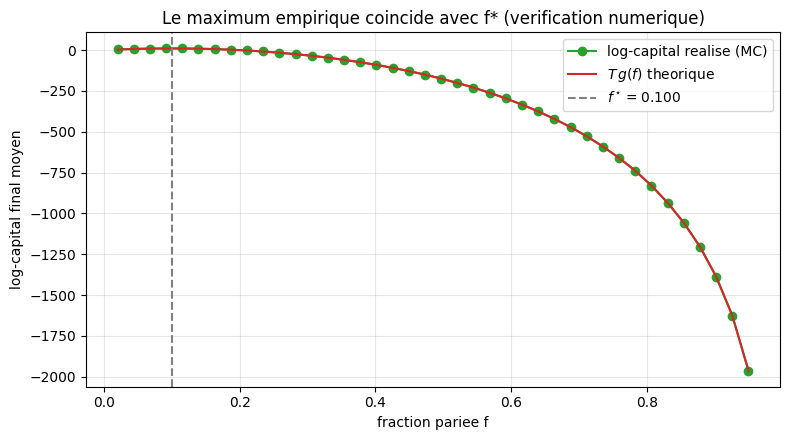

In [3]:
def simulate_log_wealth(f, p, b, T, n_paths, rng):
    # Retourne le log-capital final pour n_paths trajectoires de T paris.
    # wins ~ Bernoulli(p), taille (n_paths, T)
    wins = rng.random((n_paths, T)) < p
    # multiplicateur de richesse par pas : 1+bf (gain) ou 1-f (perte)
    mult = np.where(wins, 1.0 + b * f, 1.0 - f)
    # log-capital final = somme cumulee des log-multiplicateurs
    log_wealth = np.log(mult).sum(axis=1)
    return log_wealth

T = 2000
n_paths = 4000
rng = np.random.default_rng(seed=42)

fractions = {"sous-pari 0.5 f*": 0.5 * f_star,
             "Kelly f*": f_star,
             "sur-pari 1.5 f*": 1.5 * f_star}

print(f"Simulation : T={T} paris, n_paths={n_paths} trajectoires\n")
print(f"{'fraction':<18}{'log-W final moyen':>20}{'g(f) theorique':>18}")
for label, f in fractions.items():
    lw = simulate_log_wealth(f, p, b, T, n_paths, rng)
    print(f"{label:<18}{lw.mean():>20.3f}{T*growth(f, p, b):>18.3f}")

# Courbe : log-capital realise moyen vs fraction f
rng2 = np.random.default_rng(seed=7)
f_sweep = np.linspace(0.02, 0.95, 40)
mean_logw = np.array([simulate_log_wealth(f, p, b, T, n_paths, rng2).mean()
                      for f in f_sweep])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_sweep, mean_logw, "o-", color="#2ca02c", label="log-capital realise (MC)")
ax.plot(f_sweep, T * growth(f_sweep, p, b), "-", color="#d62728",
        label=r"$T\,g(f)$ theorique")
ax.axvline(f_star, color="grey", ls="--", label=rf"$f^\star={f_star:.3f}$")
ax.set_xlabel("fraction pariee f")
ax.set_ylabel("log-capital final moyen")
ax.set_title("Le maximum empirique coincide avec f* (verification numerique)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Ce que confirme la simulation

Le **maximum du log-capital realise** coincide avec $f^\star$ et avec le pic de
la courbe theorique $T\,g(f)$. Le sur-pari $1.5 f^\star$ croit moins vite et,
proche de $f \to 1$, une sequence malchanceuse aneantit le capital. C'est la
traduction empirique de `kelly_optimal` : **parier exactement $f^\star$**
maximise le taux de croissance du capital compose.

> **Position sizing** : dans la serie trading QuantConnect, ce resultat fonde
> le dimensionnement des positions. On l'utilise rarement a fraction pleine
> (volatilite trop forte, risque de ruine si le modele est mal specifie) ;
> le *fractional Kelly* (parier $\alpha f^\star$, $\alpha \in [0.25, 0.5]$)
> echange un peu de croissance contre une forte baisse de variance.

## 4. Exercices

Les exercices suivants sont a completer. Conformement a la regle pedagogique,
les stubs s'executent sans erreur (ils retournent `None`) : remplacez le
corps par votre solution.

### Exercice 1 — Pari defavorable et seuil de non-pari

**Contexte** : le critere de Kelly dit $f^\star \le 0$ des que $b\,p \le q$
(pari defavorable ou equitable). Dans ce cas la fraction optimale est **zero**
(ne pas parier).

**Objectif** : pour la grille de couples $(p, b)$ ci-dessous, calculer $f^\star$
et retourner `None` si $f^\star \le 0$, sinon la valeur. Verifiez que pour
$p = 0.45, b = 1.0$ (pile ou face defavorable) on obtient bien `None`.

*Indice* : `kellyFrac` peut etre negatif ; la fraction jouable est
`max(0, f_star)`.

In [4]:
def kelly_fraction_playable(p, b):
    # Retourne la fraction de Kelly jouable (0 si le pari est defavorable).
    # TODO etudiant : implementer f* = (b*p - (1-p))/b, retourner max(0, f*)
    result = None  # TODO etudiant
    return result

# Verification
for (pp, bb) in [(0.55, 1.0), (0.45, 1.0), (0.5, 1.0), (0.6, 0.8)]:
    print(f"p={pp}, b={bb} -> f* jouable = {kelly_fraction_playable(pp, bb)}")

p=0.55, b=1.0 -> f* jouable = None
p=0.45, b=1.0 -> f* jouable = None
p=0.5, b=1.0 -> f* jouable = None
p=0.6, b=0.8 -> f* jouable = None


### Exercice 2 — Fractional Kelly : compromis croissance / variance

**Contexte** : parier $\alpha f^\star$ avec $\alpha < 1$ reduit la variance du
log-capital au prix d'une croissance plus faible.

**Objectif** : pour $\alpha \in \{0.25, 0.5, 0.75, 1.0\}$, calculer (a) le
taux de croissance theorique $g(\alpha f^\star)$ et (b) l'ecart-type du
log-capital final sur $T$ paris (formule exacte ou estimation MC).

*Indice* : la variance du log-capital sur un pas est
$\mathrm{Var}[\log W] = p(1-p)\,\log^2\!\big(\tfrac{1+bf}{1-f}\big)$ ; sur $T$
pas independants elle est multipliee par $T$.

In [5]:
def fractional_kelly_tradeoff(f_star, p, b, T, alphas):
    # Retourne (liste croissance g(a*f*), liste ecart-type log-capital T pas).
    # TODO etudiant : pour chaque alpha, calculer g(alpha*f*) et std sur T pas
    growths = None  # TODO etudiant
    stds = None     # TODO etudiant
    return growths, stds

alphas = [0.25, 0.5, 0.75, 1.0]
g_vals, s_vals = fractional_kelly_tradeoff(f_star, p, b, T=2000, alphas=alphas)
if g_vals is not None:
    for a, gv, sv in zip(alphas, g_vals, s_vals):
        print(f"alpha={a:.2f} : g={gv:.5f}, std(log-W)={sv:.3f}")

### Exercice 3 — Au-dela du pari de Bernoulli

**Contexte** : le lake `kelly_lean` prouve le cas **Bernoulli** (deux issues).
Le README du lake note comme jalon ouvert la **generalisation aux distributions
non-Bernoulli** (gain/perte continus, multi-issues).

**Objectif** : pour un pari a **trois issues** — gain $+b$ avec proba $p_1$,
perte $-1$ avec proba $p_2$, neutre $0$ avec proba $p_3 = 1-p_1-p_2$ — ecrire
la fonction de croissance $g(f)$ et trouver numeriquement le $f$ qui la
maximise (par balayage puis `scipy.optimize`).

*Indice* : la richesse relative devient $1+bf$, $1-f$, $1$ ; la croissance est
$p_1\log(1+bf) + p_2\log(1-f) + p_3\log(1)$.

In [6]:
def growth_three_outcomes(f, p1, p2, b):
    # Croissance esperee pour un pari a trois issues.
    # TODO etudiant : p3 = 1 - p1 - p2 ; g = p1*log(1+bf) + p2*log(1-f) + p3*log(1)
    result = None  # TODO etudiant
    return result

def best_fraction_three_outcomes(p1, p2, b):
    # Retourne le f maximisant growth_three_outcomes (balayage grossier OK).
    # TODO etudiant : balayer f in (0,1) et retourner l'argmax
    result = None  # TODO etudiant
    return result

# Verification (a debloquer une fois implemente)
# f3 = best_fraction_three_outcomes(p1=0.45, p2=0.35, b=1.5)
# print(f"f* trois issues = {f3}")

## 5. Conclusion

| Idee cle | Traduction |
|---|---|
| Maximizer $g(f) = \mathbb{E}[\log(1+fX)]$, pas $\mathbb{E}[1+fX]$ | on optimise la **croissance composee**, pas le gain moyen d'un coup |
| $f^\star = (bp-q)/b$ | fraction optimale **unique** (theoreme `kelly_unique`) |
| Sur-pari / sous-pari | strictement sous-optimaux ; le sur-pari mene a la ruine |
| Fractional Kelly $\alpha f^\star$ | compromis pratique croissance/variance pour le *position sizing* |

**Lien avec la serie trading QuantConnect** : le critere de Kelly fonde le
dimensionnement des positions enseigne dans la Phase 3 (risk/portfolio
management). Le lake Lean [`kelly_lean`](./Kelly/Kelly.lean) en donne la
preuve formelle (0 sorry) ; ce notebook en donne l'intuition numerique et
l'outil de simulation. Reference : J. L. Kelly Jr., *A New Interpretation of
Information Rate*, BSTJ (1956).